Loading LERF model from checkpoint: 
/scratch/codepk37/anlpnerf/lerf/outputs/tools_take1/lerf/2025-10-02_175747/config.yml

[19:53:18] Auto image downscale factor of 1                                                 ]8;id=499805;file:///scratch/codepk37/condaenv/lerf/lib/python3.8/site-packages/nerfstudio/data/dataparsers/nerfstudio_dataparser.py\nerfstudio_dataparser.py]8;;\:]8;id=584696;file:///scratch/codepk37/condaenv/lerf/lib/python3.8/site-packages/nerfstudio/data/dataparsers/nerfstudio_dataparser.py#484\484]8;;\

Setting up training dataset...

Caching all 74 images.

Output()

...

✅ Done loading checkpoint from outputs/tools_take1/lerf/2025-10-02_175747/nerfstudio_models/step-000009999.ckpt

Creating camera at position (0.32751129, 0.70926067, -0.27375092), looking at (0.12751129, 0.50926067, -0.37375092)

Rendering image...

/scratch/codepk37/anlpnerf/lerf/lerf/lerf.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scales_list = torch.tensor(preset_scales)


Image saved to: /scratch/codepk37/anlpnerf/lerf/renders/my_render.png

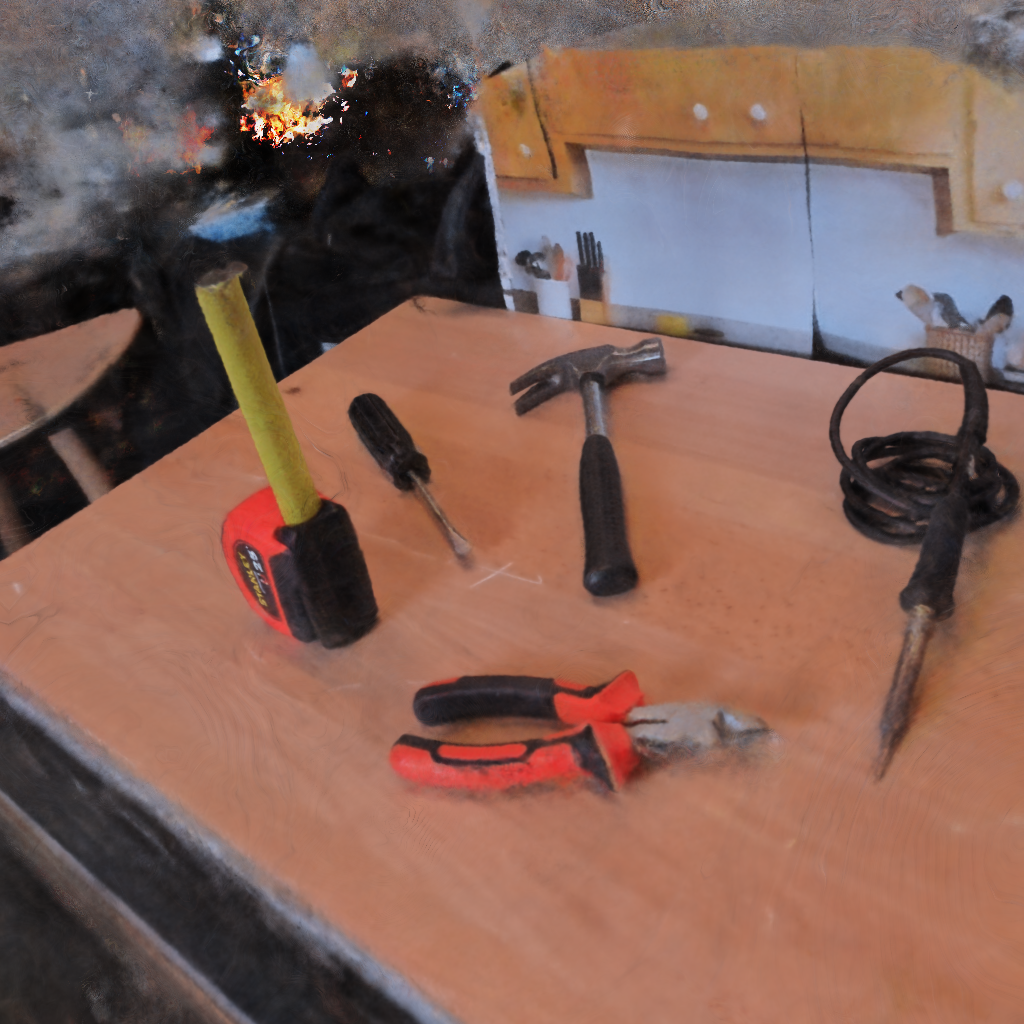

In [1]:
# Jupyter Notebook Version
import torch
import torchvision
from pathlib import Path
from rich.console import Console
from nerfstudio.utils.eval_utils import eval_setup
from nerfstudio.cameras.cameras import Cameras
from IPython.display import display
from PIL import Image

CONSOLE = Console(force_terminal=True)

# --- Helper function to compute camera-to-world matrix ---
def get_look_at_transform_manual(camera_pos: torch.Tensor, target_pos: torch.Tensor, up_vector: torch.Tensor) -> torch.Tensor:
    forward = target_pos - camera_pos
    forward = forward / torch.linalg.norm(forward)

    right = torch.cross(forward, up_vector)
    if torch.linalg.norm(right) < 1e-6:
        temp_up = torch.tensor([0.0, 0.0, 1.0], dtype=torch.float32)
        if torch.allclose(forward.abs(), temp_up.abs()):
            temp_up = torch.tensor([0.0, 1.0, 0.0], dtype=torch.float32)
        right = torch.cross(forward, temp_up)
    right = right / torch.linalg.norm(right)

    up = torch.cross(right, forward)
    up = up / torch.linalg.norm(up)

    c2w = torch.zeros((3, 4))
    c2w[:3, 0] = right
    c2w[:3, 1] = up
    c2w[:3, 2] = -forward
    c2w[:3, 3] = camera_pos
    return c2w

# --- Configuration ---
load_config_path = Path("/scratch/codepk37/anlpnerf/lerf/outputs/tools_take1/lerf/2025-10-02_175747/config.yml")
output_path = Path("/scratch/codepk37/anlpnerf/lerf/renders/my_render.png")

camera_position = (0.32751129, 0.70926067, -0.27375092)
look_at = (0.12751129, 0.50926067, -0.37375092)
up_vector = (0.0, 0.0, 1.0)
image_height = 1024
image_width = 1024
focal_length = 1111.0

# --- Load model ---
CONSOLE.print(f"Loading LERF model from checkpoint: {load_config_path}")
_, pipeline, _, _ = eval_setup(load_config_path)
model = pipeline.model.to("cuda")
model.eval()

# --- Setup camera ---
CONSOLE.print(f"Creating camera at position {camera_position}, looking at {look_at}")
camera_pos_tensor = torch.tensor(camera_position, dtype=torch.float32)
look_at_tensor = torch.tensor(look_at, dtype=torch.float32)
up_vector_tensor = torch.tensor(up_vector, dtype=torch.float32)

c2w = get_look_at_transform_manual(camera_pos=camera_pos_tensor,
                                   target_pos=look_at_tensor,
                                   up_vector=up_vector_tensor)

camera = Cameras(
    camera_to_worlds=c2w[None, ...],  # Add batch dimension
    fx=focal_length,
    fy=focal_length,
    cx=image_width / 2,
    cy=image_height / 2,
    width=image_width,
    height=image_height,
).to(model.device)

# --- Render image ---
CONSOLE.print("Rendering image...")
with torch.no_grad():
    ray_bundle = camera.generate_rays(camera_indices=0)
    outputs = model.get_outputs_for_camera_ray_bundle(ray_bundle)

rgb_image = outputs['rgb']  # H x W x 3

# --- Save image ---
output_path.parent.mkdir(parents=True, exist_ok=True)
rgb_image_chw = rgb_image.permute(2, 0, 1)  # C x H x W
torchvision.utils.save_image(rgb_image_chw, output_path)
CONSOLE.print(f"[bold green]Image saved to: {output_path}")

# --- Display in notebook ---
# Convert to PIL image for display
rgb_image_np = (rgb_image.cpu().numpy() * 255).astype("uint8")
pil_image = Image.fromarray(rgb_image_np)
display(pil_image)
